In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch import optim
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from IPython.display import clear_output
from pathlib import Path

import random, os.path, math, glob, csv, base64, itertools, sys
import gym
from gym.wrappers.record_video import RecordVideo
from pprint import pprint

# The following code is will be used to visualize the environments.

def show_video(directory):
    html = []
    for mp4 in Path(directory).glob("*.mp4"):
        video_b64 = base64.b64encode(mp4.read_bytes())
        html.append('''<video alt="{}" autoplay 
                      loop controls style="height: 400px;">
                      <source src="data:video/mp4;base64,{}" type="video/mp4" />
                 </video>'''.format(mp4, video_b64.decode('ascii')))
    ipythondisplay.display(ipythondisplay.HTML(data="<br>".join(html)))
    
display = Display(visible=0, size=(1400, 900))
display.start()

def make_seed(seed):
    np.random.seed(seed=seed)
    torch.manual_seed(seed=seed)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gym


class ActorNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=-1)
        return x


class ValueNetwork(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim


class A2CAgent:
    def __init__(self, obs_dim, hidden_size, action_dim, actor_lr, critic_lr, gamma, entropy_coef):
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.actor = ActorNetwork(obs_dim, hidden_size, action_dim)
        self.critic = ValueNetwork(obs_dim, hidden_size)

        self.actor_optimizer = optim.RMSprop(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.RMSprop(self.critic.parameters(), lr=critic_lr)

    def select_action(self, obs):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            policy = self.actor(obs_tensor)
            value = self.critic(obs_tensor)

        dist = torch.distributions.Categorical(policy)
        action = dist.sample()

        return action.item(), value.item()

    def greedy_action(self, obs):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            policy = self.actor(obs_tensor)
            action = torch.argmax(policy, dim=1)

        return action.item()

    def optimize(self, observations, actions, rewards, dones, next_value):
        T = len(rewards)

        returns = np.zeros(T, dtype=np.float32)
        future = next_value

        for t in reversed(range(T)):
            future = rewards[t] + self.gamma * future * (1 - float(dones[t]))
            returns[t] = future

        observations = torch.tensor(np.array(observations), dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64)
        returns = torch.tensor(returns, dtype=torch.float32).unsqueeze(1)

        values = self.critic(observations)
        advantages = returns - values.detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        critic_loss = F.mse_loss(values, returns)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        policy = self.actor(observations)
        dist = torch.distributions.Categorical(policy)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy().mean()

        actor_loss = -(log_probs * advantages.squeeze(1)).mean() - self.entropy_coef * entropy

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        return actor_loss.item(), critic_loss.item()

    def save(self, path):
        torch.save({
            "actor_state_dict": self.actor.state_dict(),
            "critic_state_dict": self.critic.state_dict(),
            "actor_optimizer_state_dict": self.actor_optimizer.state_dict(),
            "critic_optimizer_state_dict": self.critic_optimizer.state_dict(),
        }, path)

    def load(self, path, load_optimizers=True):
        checkpoint = torch.load(path, map_location="cpu")
        self.actor.load_state_dict(checkpoint["actor_state_dict"])
        self.critic.load_state_dict(checkpoint["critic_state_dict"])

        if load_optimizers:
            self.actor_optimizer.load_state_dict(checkpoint["actor_optimizer_state_dict"])
            self.critic_optimizer.load_state_dict(checkpoint["critic_optimizer_state_dict"])

In [4]:
import os
import gym
import numpy as np
import torch


class IndependentA2CAgent:
    def __init__(self, config):
        self.config = config
        self.env = gym.make(config["env_id"])
        self.gamma = config["gamma"]

        np.random.seed(config["seed"])
        torch.manual_seed(config["seed"])

        try:
            self.env.reset(seed=config["seed"])
        except:
            pass

        out = self.env.reset()
        if isinstance(out, tuple):
            obs_n, _ = out
        else:
            obs_n = out

        obs_n = np.array(obs_n, dtype=np.float32)

        self.n_agents = obs_n.shape[0]
        self.obs_dim = obs_n.shape[1]
        self.action_dim = self.env.action_space[0].n

        self.agents = [
            A2CAgent(
                obs_dim=self.obs_dim,
                hidden_size=config["hidden_size"],
                action_dim=self.action_dim,
                actor_lr=config["actor_network"]["learning_rate"],
                critic_lr=config["value_network"]["learning_rate"],
                gamma=config["gamma"],
                entropy_coef=config["entropy"],
            )
            for _ in range(self.n_agents)
        ]

    def training_batch(self, epochs, batch_size, save_dir="independent_a2c_ckpt"):
        os.makedirs(save_dir, exist_ok=True)

        out = self.env.reset()
        if isinstance(out, tuple):
            obs_n, _ = out
        else:
            obs_n = out

        obs_n = np.array(obs_n, dtype=np.float32)
        reward_history = []

        best_eval_reward = -float("inf")

        for epoch in range(epochs):
            batch_obs = [[] for _ in range(self.n_agents)]
            batch_actions = [[] for _ in range(self.n_agents)]
            batch_rewards = [[] for _ in range(self.n_agents)]
            batch_dones = [[] for _ in range(self.n_agents)]

            for _ in range(batch_size):
                actions = []
                values = []

                for i in range(self.n_agents):
                    a, v = self.agents[i].select_action(obs_n[i])
                    actions.append(a)
                    values.append(v)

                step_out = self.env.step(actions)

                if len(step_out) == 5:
                    next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    next_obs_n, reward_n, done_n, info = step_out

                next_obs_n = np.array(next_obs_n, dtype=np.float32)

                for i in range(self.n_agents):
                    batch_obs[i].append(obs_n[i].copy())
                    batch_actions[i].append(actions[i])
                    batch_rewards[i].append(reward_n[i])
                    batch_dones[i].append(done_n[i])

                obs_n = next_obs_n

                if all(done_n):
                    out = self.env.reset()
                    if isinstance(out, tuple):
                        obs_n, _ = out
                    else:
                        obs_n = out
                    obs_n = np.array(obs_n, dtype=np.float32)

            actor_losses, critic_losses = [], []

            for i in range(self.n_agents):
                obs_tensor = torch.tensor(obs_n[i], dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    next_value = self.agents[i].critic(obs_tensor).item()

                a_loss, c_loss = self.agents[i].optimize(
                    batch_obs[i],
                    batch_actions[i],
                    batch_rewards[i],
                    batch_dones[i],
                    next_value,
                )
                actor_losses.append(a_loss)
                critic_losses.append(c_loss)

            joint_batch_reward = np.mean([np.sum(batch_rewards[i]) for i in range(self.n_agents)])
            reward_history.append(joint_batch_reward)

            if epoch % 20 == 0 or epoch == epochs - 1:
                eval_reward = self.evaluate(n_episodes=5)
                print(
                    f"Epoch {epoch}/{epochs} | "
                    f"Eval reward: {eval_reward:.3f} | "
                    f"Actor loss: {np.mean(actor_losses):.4f} | "
                    f"Critic loss: {np.mean(critic_losses):.4f}"
                )

                if eval_reward > best_eval_reward:
                    best_eval_reward = eval_reward
                    self.save(save_dir)
                    print(f"Best model saved in: {save_dir}")

        return reward_history
    
    def evaluate(self, n_episodes=5):
        episode_rewards = []

        for _ in range(n_episodes):
            out = self.env.reset()
            if isinstance(out, tuple):
                obs_n, _ = out
            else:
                obs_n = out

            obs_n = np.array(obs_n, dtype=np.float32)
            done_n = [False] * self.n_agents
            total_reward = np.zeros(self.n_agents, dtype=np.float32)

            while not all(done_n):
                actions = [self.agents[i].greedy_action(obs_n[i]) for i in range(self.n_agents)]

                step_out = self.env.step(actions)
                if len(step_out) == 5:
                    obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    obs_n, reward_n, done_n, info = step_out

                obs_n = np.array(obs_n, dtype=np.float32)
                total_reward += np.array(reward_n, dtype=np.float32)

            episode_rewards.append(total_reward.sum())

        return float(np.mean(episode_rewards))
    
    def save(self, save_dir="independent_a2c_ckpt"):
        os.makedirs(save_dir, exist_ok=True)
        for i, agent in enumerate(self.agents):
            agent.save(os.path.join(save_dir, f"agent_{i}.pth"))

    def load(self, save_dir="independent_a2c_ckpt", load_optimizers=False):
        for i, agent in enumerate(self.agents):
            agent.load(os.path.join(save_dir, f"agent_{i}.pth"), load_optimizers=load_optimizers)

In [8]:
config = {
    "env_id": "ma_gym:Combat-v0",
    "seed": 42,
    "gamma": 0.99,
    "entropy": 0.02,
    "hidden_size": 128,
    "actor_network": {"learning_rate": 3e-4},
    "value_network": {"learning_rate": 1e-3},
}

agent = IndependentA2CAgent(config)

rewards = agent.training_batch(
    epochs=2000,
    batch_size=256,
    save_dir="independent_a2c_combat"
)

You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 0/2000 | Eval reward: -13.000 | Actor loss: -0.0440 | Critic loss: 2.6603
Best model saved in: independent_a2c_combat


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 20/2000 | Eval reward: -12.800 | Actor loss: -0.0447 | Critic loss: 0.2784
Best model saved in: independent_a2c_combat


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


...

Epoch 1940/2000 | Eval reward: -11.000 | Actor loss: 0.0127 | Critic loss: 0.4515


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1960/2000 | Eval reward: -10.000 | Actor loss: -0.0439 | Critic loss: 0.3702


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1980/2000 | Eval reward: -11.200 | Actor loss: -0.0852 | Critic loss: 0.5952
Epoch 1999/2000 | Eval reward: -5.400 | Actor loss: 0.0080 | Critic loss: 0.3652


In [5]:
config = {
    "env_id": "ma_gym:Combat-v0",
    "seed": 42,
    "gamma": 0.99,
    "entropy": 0.02,
    "hidden_size": 128,
    "actor_network": {"learning_rate": 3e-4},
    "value_network": {"learning_rate": 1e-3},
}

agent = IndependentA2CAgent(config)


In [6]:
import gym
import numpy as np
import torch
import imageio.v2 as imageio
from IPython.display import Image, display

def play_and_make_gif_independent(agent, gif_path="i_a2c_combat.gif", max_ep_len=400, greedy=True, fps=10):
    frames = []

    out = agent.env.reset()
    if isinstance(out, tuple):
        obs_n, _ = out
    else:
        obs_n = out

    obs_n = np.array(obs_n, dtype=np.float32)
    done_n = [False] * agent.n_agents
    ep_reward = 0

    for _ in range(max_ep_len):
        actions = []

        with torch.no_grad():
            for i in range(agent.n_agents):
                obs_tensor = torch.tensor(obs_n[i], dtype=torch.float32).unsqueeze(0)
                policy = agent.agents[i].actor(obs_tensor)

                if greedy:
                    action = torch.argmax(policy, dim=1).item()
                else:
                    dist = torch.distributions.Categorical(policy)
                    action = dist.sample().item()

                actions.append(action)

        step_out = agent.env.step(actions)

        if len(step_out) == 5:
            next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
            done_n = np.logical_or(terminated_n, truncated_n)
        else:
            next_obs_n, reward_n, done_n, info = step_out

        ep_reward += float(np.sum(reward_n))
        obs_n = np.array(next_obs_n, dtype=np.float32)

        frame = agent.env.render(mode="rgb_array")
        frames.append(frame)

        if all(done_n):
            break

    imageio.mimsave(gif_path, frames, fps=fps)
    print("Episode reward:", ep_reward)
    return gif_path

Episode reward: -13.0


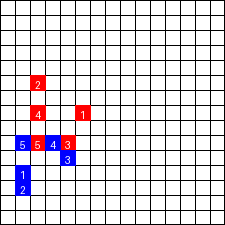

In [17]:
agent.load("independent_a2c_combat", load_optimizers=False)

gif_path = play_and_make_gif_independent(
    agent,
    gif_path="i_a2c_combat.gif",
    max_ep_len=400,
    greedy=False,
    fps=10
)

display(Image(filename=gif_path))